# Logistic Regression Exercise: User Action Prediction

## 1. Setup, Imports and Data Loading

Import necessary libraries, load the generated 'User Action' dataset, import our custom Logistic Regression implementation (assuming `mlab.classification.LogisticRegression`), and relevant sklearn modules for classification tasks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression as SkLogisticRegression  # Alias
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

# --- Import your custom implementations ---
from mlab.regression._logistic import LogisticRegression


# Evaluation function for classification
def evaluate_classification(y_true, y_pred, model_name):
    """Calculates and prints classification metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=['Action=0', 'Action=1'])

    print(f"--- Evaluation ({model_name}) ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    # Visualize Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Action=0', 'Action=1'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix ({model_name})')
    plt.show()
    print("\nClassification Report:")
    print(cr)
    # Return accuracy for potential comparison tables
    return {'Accuracy': accuracy, 'ConfusionMatrix': cm, 'ClassificationReport': cr}


# Set plot style
sns.set_theme(style="whitegrid")

# Load the dataset
DATA_FILENAME = "datasets/user_actions.csv"  # Make sure this file exists
try:
    df = pd.read_csv(DATA_FILENAME)
except FileNotFoundError:
    print(f"Error: Dataset file '{DATA_FILENAME}' not found.")
    df = pd.DataFrame()

if not df.empty:
    print("Dataset loaded successfully.")
    print(f"Shape: {df.shape}")
    print("\nFirst 5 rows:")
    print(df.head())

Dataset loaded successfully.
Shape: (10000, 3)

First 5 rows:
   metric_A  metric_B  action_taken
0  1.221228  8.719692             0
1  7.448653  4.664254             0
2  4.225950  4.437819             1
3  7.332529  8.126657             0
4  2.682475  1.119040             0


## 2. Data Analysis 

Visualize the **entire dataset** to understand the relationship between the metrics and the user action.

Basic Descriptive Statistics (Full Dataset):
           metric_A      metric_B  action_taken
count  10000.000000  10000.000000  10000.000000
mean       4.977459      4.906478      0.350000
std        3.380279      3.383722      0.476993
min       -3.955423     -3.882872      0.000000
25%        2.724770      2.643324      0.000000
50%        4.953356      4.872454      0.000000
75%        7.234162      7.162990      1.000000
max       13.859027     14.076629      1.000000

Class Distribution:
action_taken
0    0.65
1    0.35
Name: proportion, dtype: float64


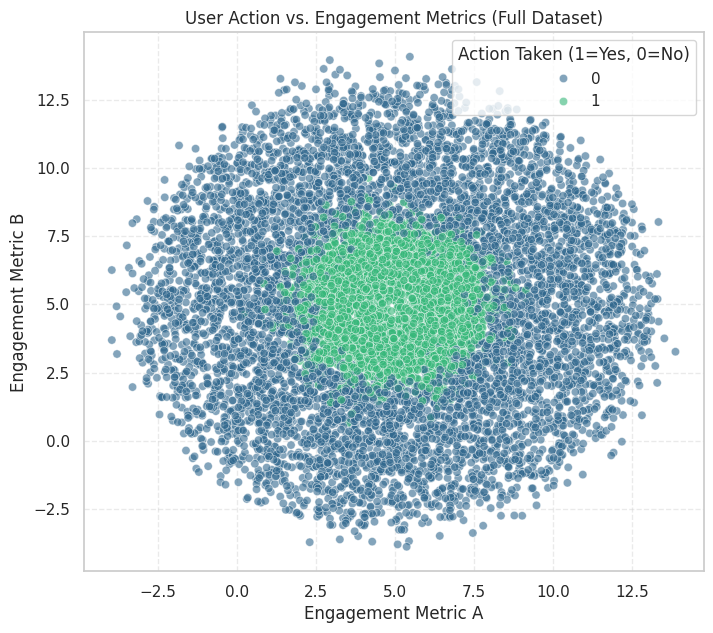

In [2]:
# --- Basic Statistics --- 
if not df.empty:
    print("Basic Descriptive Statistics (Full Dataset):")
    print(df.describe())
    print("\nClass Distribution:")
    print(df['action_taken'].value_counts(normalize=True))
else:
    print("Dataset empty, skipping EDA.")

# --- Visualization --- 
if not df.empty:
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=df, x='metric_A', y='metric_B',
                    hue='action_taken', palette='viridis', alpha=0.6)
    plt.title('User Action vs. Engagement Metrics (Full Dataset)')
    plt.xlabel('Engagement Metric A')
    plt.ylabel('Engagement Metric B')
    plt.legend(title='Action Taken (1=Yes, 0=No)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()
else:
    print("Dataset empty, skipping visualization.")

## 3. Train-Test Split

We split the data into training and testing sets.

In [3]:
X = df[['metric_A', 'metric_B']].values
y = df['action_taken'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Feature Scaling

Logistic Regression, especially when using Gradient Descent or regularization, benefits from feature scaling. **Fit the scaler only on the training data.**

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("metric_A mean before scaling:", np.mean(X_train[:, 0]))
print("metric_A mean after scaling:", np.mean(X_train_scaled[:, 0]))

print("metric_B mean before scaling:", np.mean(X_train[:, 1]))
print("metric_B mean after scaling:", np.mean(X_train_scaled[:, 1]))

metric_A mean before scaling: 4.977385240254945
metric_A mean after scaling: -5.567546423890235e-15
metric_B mean before scaling: 4.8953218660704
metric_B mean after scaling: 3.388844760365828e-15


## 5. Logistic Regression (Using `mlab.classification.LogisticRegression`)

Fit the custom logistic regression model.

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = LogisticRegression().fit(X_train_scaled, y_train).predict(X_test_scaled)

conf_matrix_scratch = confusion_matrix(y_test, y_pred)
class_report_scratch = classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)'])

print("\nMy Confusion Matrix:")
print(conf_matrix_scratch)

print("\nMy Classification Report:")
print(class_report_scratch)


My Confusion Matrix:
[[ 130 1170]
 [   0  700]]

My Classification Report:
              precision    recall  f1-score   support

      No (0)       1.00      0.10      0.18      1300
     Yes (1)       0.37      1.00      0.54       700

    accuracy                           0.41      2000
   macro avg       0.69      0.55      0.36      2000
weighted avg       0.78      0.41      0.31      2000



## 6. Using Scikit-learn 

Compare our results with Scikit-learn.

In [6]:
model_sk = SkLogisticRegression(max_iter=1000)
model_sk.fit(X_train_scaled, y_train)
y_pred_sk = model_sk.predict(X_test_scaled)

print("\nSimple Sckit-learn Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_sk))
print("\nSimple Sckit-learn Classification Report:")
print(classification_report(y_test, y_pred_sk))


Simple Sckit-learn Confusion Matrix:
[[1300    0]
 [ 700    0]]

Simple Sckit-learn Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79      1300
           1       0.00      0.00      0.00       700

    accuracy                           0.65      2000
   macro avg       0.33      0.50      0.39      2000
weighted avg       0.42      0.65      0.51      2000



/home/optimus/My Kingdom/Projects/nptorch/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/optimus/My Kingdom/Projects/nptorch/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/optimus/My Kingdom/Projects/nptorch/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [7]:
pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", SkLogisticRegression())
])

pipeline.fit(X_train_scaled, y_train)
y_pred_sk = pipeline.predict(X_test_scaled)

print("\nPoly Sckit-learn Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_sk))
print("\nPoly Sckit-learn Classification Report:")
print(classification_report(y_test, y_pred_sk))


Poly Sckit-learn Confusion Matrix:
[[1242   58]
 [  46  654]]

Poly Sckit-learn Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1300
           1       0.92      0.93      0.93       700

    accuracy                           0.95      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.95      0.95      0.95      2000

